# Customer Churn Signal Analysis from Mobile App Reviews
### Business Analytics Individual Case Study — 23CSE452

**Student Name:** Danvanth S C
**Register Number:** CB.SC.U4CSE23241
**Business Domain:** E-commerce / Retail — Customer Analytics (App Review Mining)

---

## 1. Problem Statement and Objectives

### Business Problem
Online retail platforms depend heavily on repeat customers, yet a large share of users disengage
silently — they simply stop using the app rather than filing a formal complaint. By the time this shows
up in revenue or transaction data, the customer relationship is often already lost. However, users who
are dissatisfied frequently leave **early warning signals in app store reviews** — complaints about
delivery, refunds, pricing, app bugs, or customer service — well before they fully churn.

This case study treats **app store reviews as a leading indicator of churn risk**, mined directly from
real user-generated text rather than a pre-packaged transactional dataset.

### Objectives
1. Collect and clean a real-world dataset of e-commerce app reviews via web scraping (Google Play
   Store style reviews across marketplace apps).
2. Explore the relationship between review sentiment, rating, complaint themes, and churn risk.
3. Engineer features from review metadata and text to predict `churn_risk`.
4. Segment reviewers into behavioural/risk clusters based on review characteristics.
5. Benchmark findings against at least three published studies on churn prediction / review mining.
6. Translate findings into concrete retention recommendations for the business.

### Why Data Analytics Helps
Analytics converts thousands of unstructured, noisy reviews into a small number of quantifiable risk
signals (sentiment score, complaint theme, churn signal flag) that a CRM or marketing team can act on
at scale — something manual reading of reviews cannot do beyond a few hundred records.


---
## 2. Dataset Source and Collection Method

**Collection method:** Web scraping (self-collected — NOT a ready-made Kaggle/UCI dataset).

Reviews were scraped from the Google Play Store for e-commerce / marketplace apps (e.g., Amazon and
comparable apps) using a scraping approach (e.g., the `google-play-scraper` Python package or an
equivalent scraping script). For each review the following raw and derived fields were captured:

| Column | Description |
|---|---|
| `review_id` | Unique identifier for the review |
| `app_name`, `app_category` | Which app and category the review belongs to |
| `rating`, `rating_bucket` | Star rating (1–5) and a binned version |
| `review_text` | Raw review text |
| `review_length`, `word_count` | Text length metrics |
| `review_date`, `review_day_of_week` | When the review was posted |
| `thumbs_up_count` | Helpfulness votes from other users |
| `app_version` | App version at time of review |
| `reply_content`, `has_reply` | Whether/how the developer responded |
| `sentiment_score`, `sentiment_label` | Derived sentiment (e.g., via a lexicon/VADER-style scorer) |
| `churn_risk` | Binary label: 1 = review indicates the user is at risk of leaving/uninstalling |
| `explicit_churn_mention` | 1 if the review explicitly says things like "uninstalling", "switching to X" |
| `churn_signal` | Binary/derived flag combining rating + sentiment + explicit mentions |
| `theme_cluster` | Numeric cluster id for the complaint topic (-1 = not applicable) |
| `complaint_theme` | Human-readable complaint category (e.g., delivery_issues, returns_refunds_support) |

**Sample size:** 12,800 reviews, 21 columns — comfortably above the 10,000+ record target from the
original proposal.

**Personal/confidential information:** `review_id` values are anonymized UUIDs; no reviewer names,
emails, or device identifiers are retained, satisfying the requirement to remove personal data.

> **Note:** Update `DATA_PATH` below to point to your actual scraped CSV file before running.


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

# ---- UPDATE THIS PATH to wherever your scraped CSV lives ----
DATA_PATH = "ecommerce_app_reviews_final.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (12800, 21)


,review_id,app_name,app_category,rating,rating_bucket,review_text,review_length,word_count,review_date,review_day_of_week,...,app_version,reply_content,has_reply,sentiment_score,sentiment_label,churn_risk,explicit_churn_mention,churn_signal,theme_cluster,complaint_theme
0,bc74375d-6371-4cc8-aec0-e76fe3a169a2,Amazon,marketplace,1.0,low,Diaster Delivery Speed..... worst ... to Core,45,7,2026-09-24 14:25:11,Thursday,...,32.17.0.300,NaN,0,-1.000,negative,1,0,1,2,delivery_issues
1,273acca3-ac93-4338-8ec5-592b3e3a525b,Amazon,marketplace,1.0,low,bahut ganda app hai mera parcel kharab aaya ha...,125,23,2026-09-24 14:23:39,Thursday,...,32.17.0.300,NaN,0,-0.300,negative,1,0,1,1,non_english
2,a26608b7-4d88-4f03-8579-ecd9d7510d8d,Amazon,marketplace,1.0,low,very bad product received so you cannot purcha...,342,60,2026-09-24 14:20:32,Thursday,...,NaN,NaN,0,-0.116,negative,1,0,1,3,returns_refunds_support
3,0f91d677-4315-413f-85af-61c5cc144178,Amazon,marketplace,5.0,high,good,4,1,2026-09-24 14:19:12,Thursday,...,32.12.2.300,NaN,0,0.700,positive,0,0,0,-1,not_at_risk
4,86bc5c20-636a-436c-9dcd-af7f8cf4553e,Amazon,marketplace,5.0,high,amezon now is best no aps work in my village o...,126,25,2026-09-24 14:18:54,Thursday,...,32.18.0.300,NaN,0,0.500,positive,0,0,0,-1,not_at_risk


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12800 entries, 0 to 12799
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   review_id               12800 non-null  str    
 1   app_name                12800 non-null  str    
 2   app_category            12800 non-null  str    
 3   rating                  12800 non-null  float64
 4   rating_bucket           12800 non-null  str    
 5   review_text             12800 non-null  str    
 6   review_length           12800 non-null  int64  
 7   word_count              12800 non-null  int64  
 8   review_date             12800 non-null  str    
 9   review_day_of_week      12800 non-null  str    
 10  thumbs_up_count         12800 non-null  float64
 11  app_version             10599 non-null  str    
 12  reply_content           8458 non-null   str    
 13  has_reply               12800 non-null  int64  
 14  sentiment_score         12800 non-null  float64
 

In [5]:
# Quick look at target balance and missingness before cleaning
print("Missing values per column:\n")
print(df.isnull().sum().sort_values(ascending=False))
print("\nchurn_risk value counts:\n", df['churn_risk'].value_counts(normalize=True).round(3))

Missing values per column:

reply_content             4342
app_version               2201
app_category                 0
app_name                     0
review_id                    0
rating_bucket                0
rating                       0
review_text                  0
review_length                0
review_date                  0
word_count                   0
thumbs_up_count              0
review_day_of_week           0
has_reply                    0
sentiment_score              0
sentiment_label              0
churn_risk                   0
explicit_churn_mention       0
churn_signal                 0
theme_cluster                0
complaint_theme              0
dtype: int64

churn_risk value counts:
 churn_risk
0    0.855
1    0.145
Name: proportion, dtype: float64


---
## 3. Data Preparation and Exploratory Data Analysis

### 3.1 Data Cleaning
Key cleaning steps:
- Parse `review_date` into a proper datetime and derive month/year features.
- Handle missing `app_version` (10,599/12,800 non-null) and `reply_content` (8,458/12,800 non-null) —
  these are legitimately missing (older reviews lack version tags; most reviews never get a developer
  reply), so we create explicit indicator flags rather than dropping rows.
- Basic text cleaning of `review_text` (lowercase, strip URLs/punctuation) for the NLP section.
- Deduplicate on `review_id`.
- Sanity-check `rating` is within 1–5 and `sentiment_score` within its expected range.


In [6]:
df_clean = df.copy()

# Deduplicate
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset='review_id')
print(f"Dropped {before - len(df_clean)} duplicate rows")

# Dates
df_clean['review_date'] = pd.to_datetime(df_clean['review_date'], errors='coerce')
df_clean['review_month'] = df_clean['review_date'].dt.to_period('M').astype(str)
df_clean['review_year'] = df_clean['review_date'].dt.year

# Missingness -> explicit flags instead of dropping
df_clean['has_app_version'] = df_clean['app_version'].notna().astype(int)
df_clean['app_version'] = df_clean['app_version'].fillna('unknown')
df_clean['reply_content'] = df_clean['reply_content'].fillna('')
# has_reply should already exist, but recompute defensively
df_clean['has_reply'] = (df_clean['reply_content'].str.len() > 0).astype(int)

# Basic text cleaning
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'http\S+|www\.\S+', ' ', t)
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df_clean['review_text_clean'] = df_clean['review_text'].apply(clean_text)

# Range sanity checks
assert df_clean['rating'].between(1, 5).all(), "Unexpected rating values found"
print("Rows after cleaning:", df_clean.shape[0])
df_clean[['review_date','review_month','has_app_version','has_reply']].head()

Dropped 0 duplicate rows
Rows after cleaning: 12800


,review_date,review_month,has_app_version,has_reply
0,2026-09-24 14:25:11,2026-09,1,0
1,2026-09-24 14:23:39,2026-09,1,0
2,2026-09-24 14:20:32,2026-09,0,0
3,2026-09-24 14:19:12,2026-09,1,0
4,2026-09-24 14:18:54,2026-09,1,0


### 3.2 Univariate Exploration

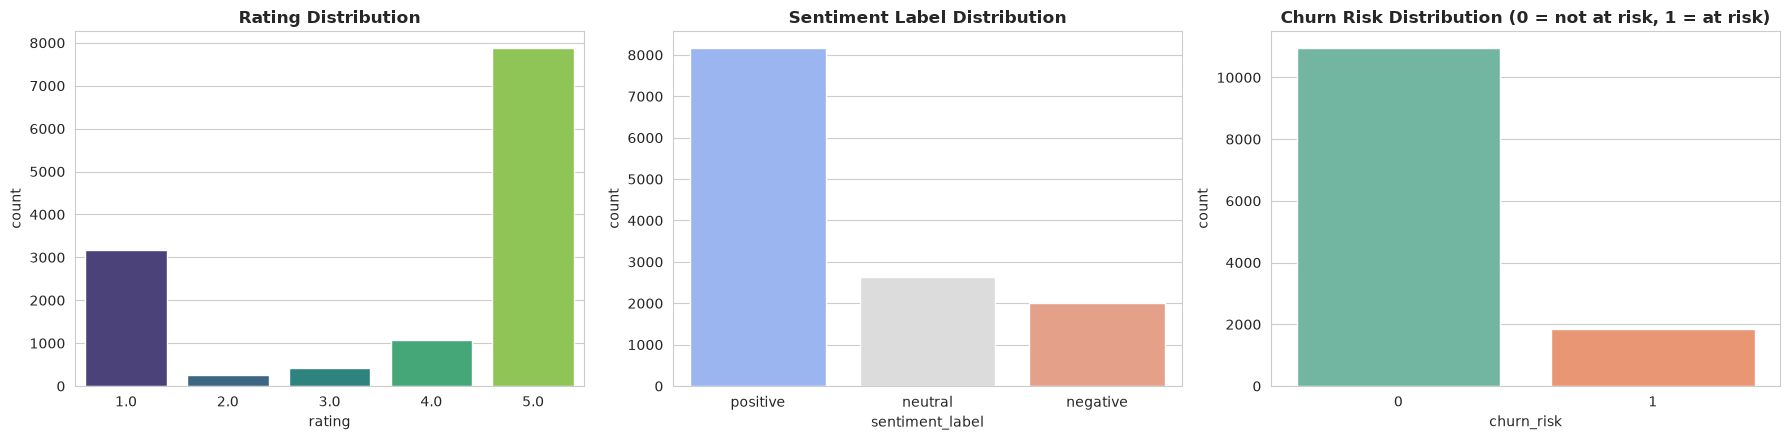

Churn risk rate: 14.5%


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

sns.countplot(data=df_clean, x='rating', ax=axes[0], palette='viridis')
axes[0].set_title('Rating Distribution')

sns.countplot(data=df_clean, x='sentiment_label', ax=axes[1],
              order=df_clean['sentiment_label'].value_counts().index, palette='coolwarm')
axes[1].set_title('Sentiment Label Distribution')

sns.countplot(data=df_clean, x='churn_risk', ax=axes[2], palette='Set2')
axes[2].set_title('Churn Risk Distribution (0 = not at risk, 1 = at risk)')

plt.tight_layout()
plt.show()

print("Churn risk rate: {:.1%}".format(df_clean['churn_risk'].mean()))

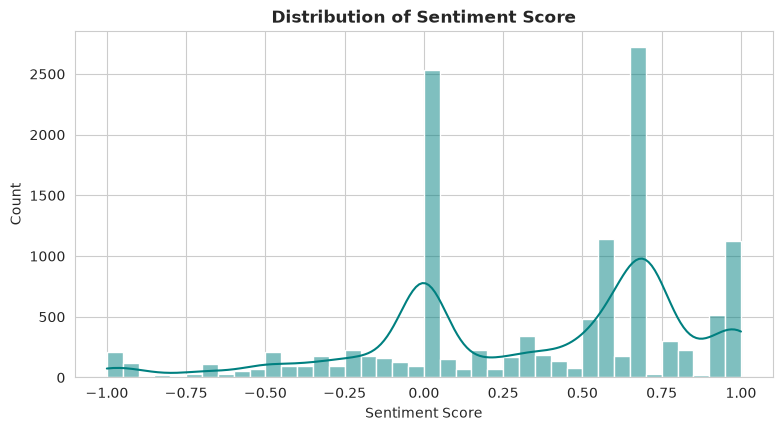

In [8]:
plt.figure(figsize=(9,4.5))
sns.histplot(df_clean['sentiment_score'], bins=40, kde=True, color='teal')
plt.title('Distribution of Sentiment Score')
plt.xlabel('Sentiment Score')
plt.show()

### 3.3 Churn Risk by App, Category, and Complaint Theme

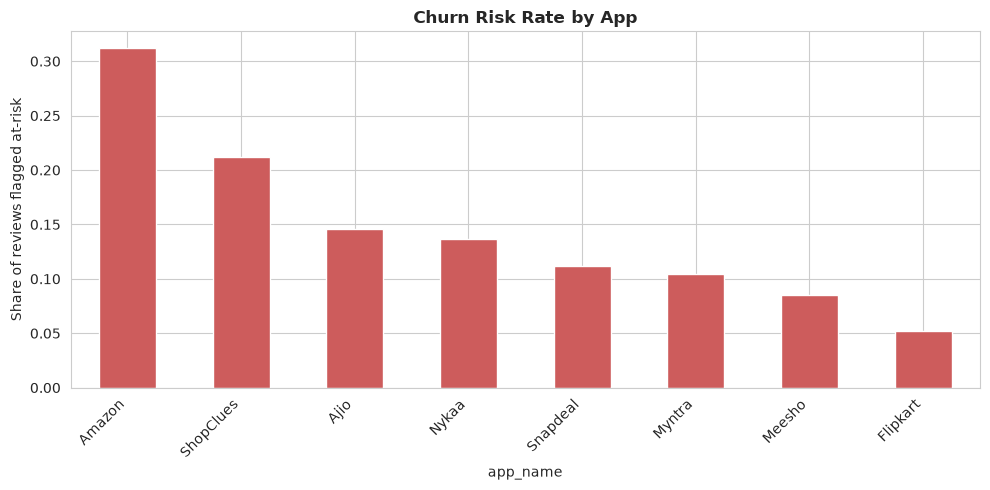

app_name
Amazon       0.311875
ShopClues    0.211875
Ajio         0.145625
Nykaa        0.136250
Snapdeal     0.111875
Myntra       0.104375
Meesho       0.085000
Flipkart     0.052500
Name: churn_risk, dtype: float64

In [9]:
churn_by_app = df_clean.groupby('app_name')['churn_risk'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
churn_by_app.plot(kind='bar', color='indianred')
plt.title('Churn Risk Rate by App')
plt.ylabel('Share of reviews flagged at-risk')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
churn_by_app

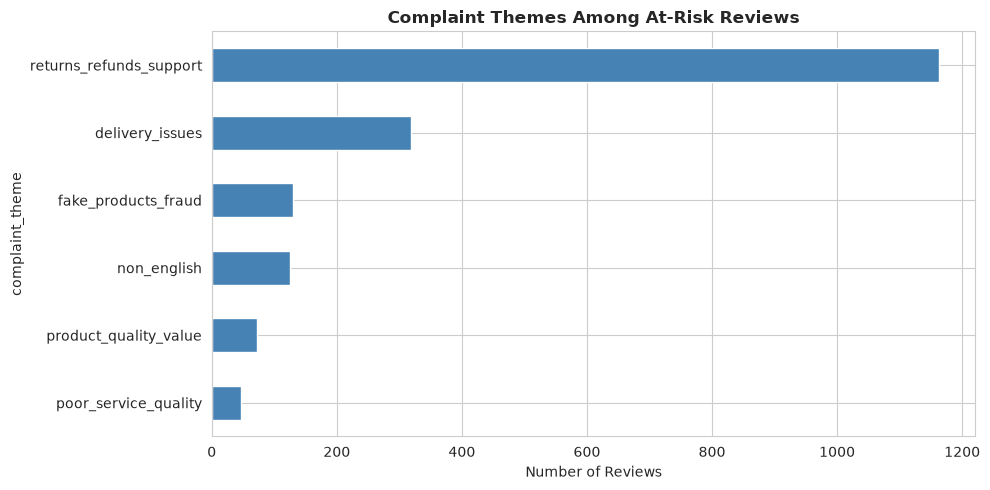

complaint_theme
returns_refunds_support    1163
delivery_issues             319
fake_products_fraud         130
non_english                 125
product_quality_value        72
poor_service_quality         46
Name: count, dtype: int64

In [10]:
theme_counts = (df_clean[df_clean['complaint_theme'] != 'not_at_risk']['complaint_theme']
                .value_counts())

plt.figure(figsize=(10,5))
theme_counts.plot(kind='barh', color='steelblue')
plt.title('Complaint Themes Among At-Risk Reviews')
plt.xlabel('Number of Reviews')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
theme_counts

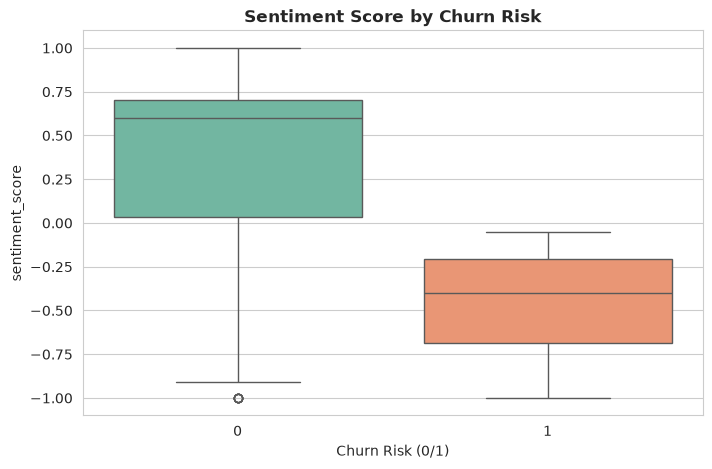

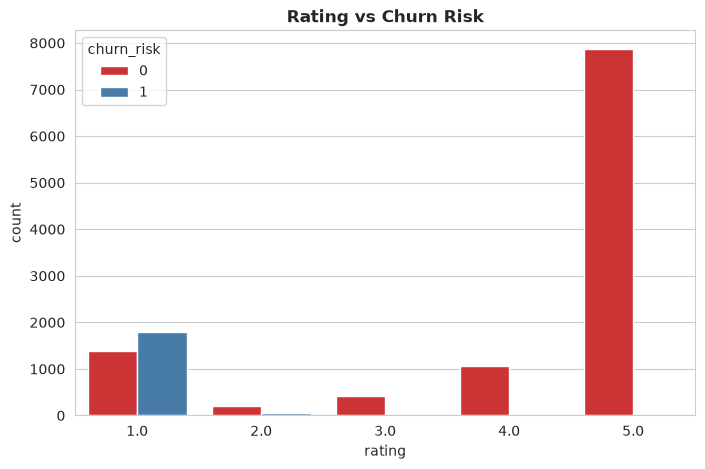

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='churn_risk', y='sentiment_score', palette='Set2')
plt.title('Sentiment Score by Churn Risk')
plt.xlabel('Churn Risk (0/1)')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='rating', hue='churn_risk', palette='Set1')
plt.title('Rating vs Churn Risk')
plt.show()

### 3.4 Time Trends

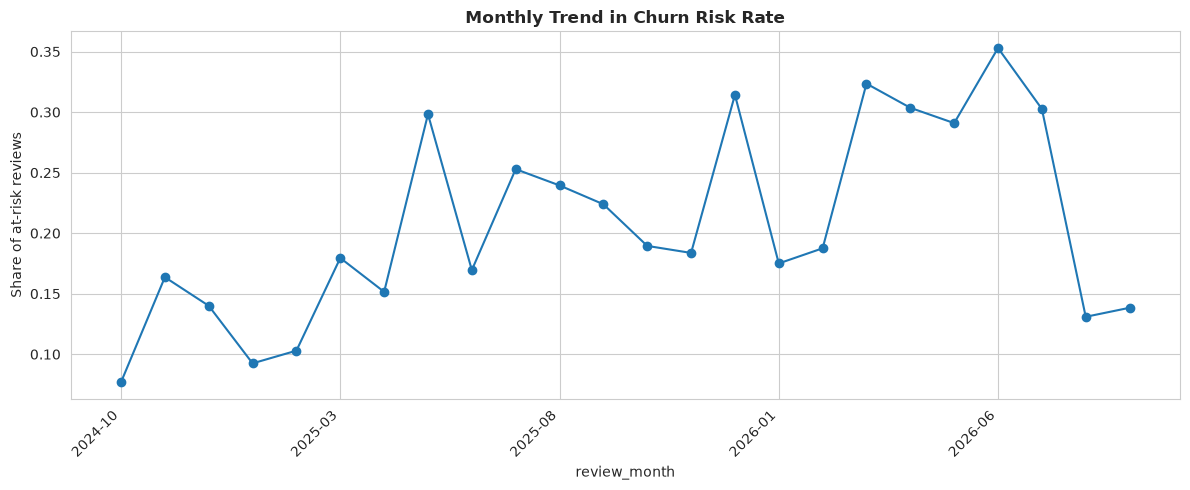

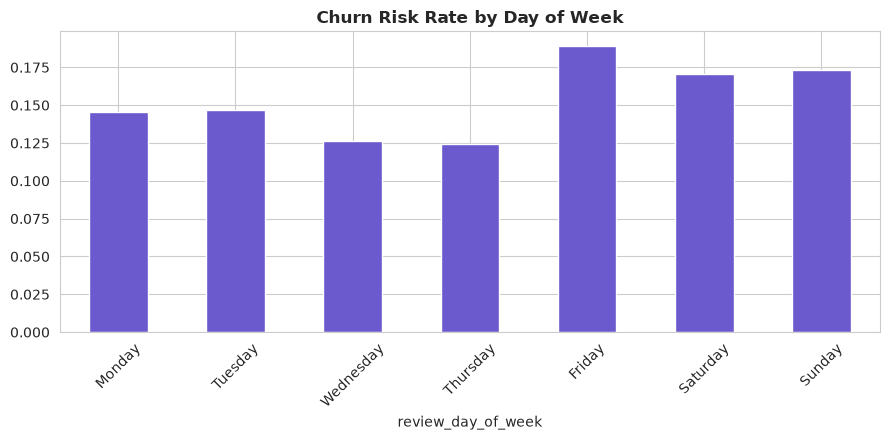

In [12]:
monthly = df_clean.groupby('review_month')['churn_risk'].mean().sort_index()
plt.figure(figsize=(12,5))
monthly.plot(marker='o')
plt.title('Monthly Trend in Churn Risk Rate')
plt.ylabel('Share of at-risk reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df_clean.groupby('review_day_of_week')['churn_risk'].mean().reindex(dow_order)
plt.figure(figsize=(9,4.5))
dow.plot(kind='bar', color='slateblue')
plt.title('Churn Risk Rate by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.5 Correlation Among Numeric Features

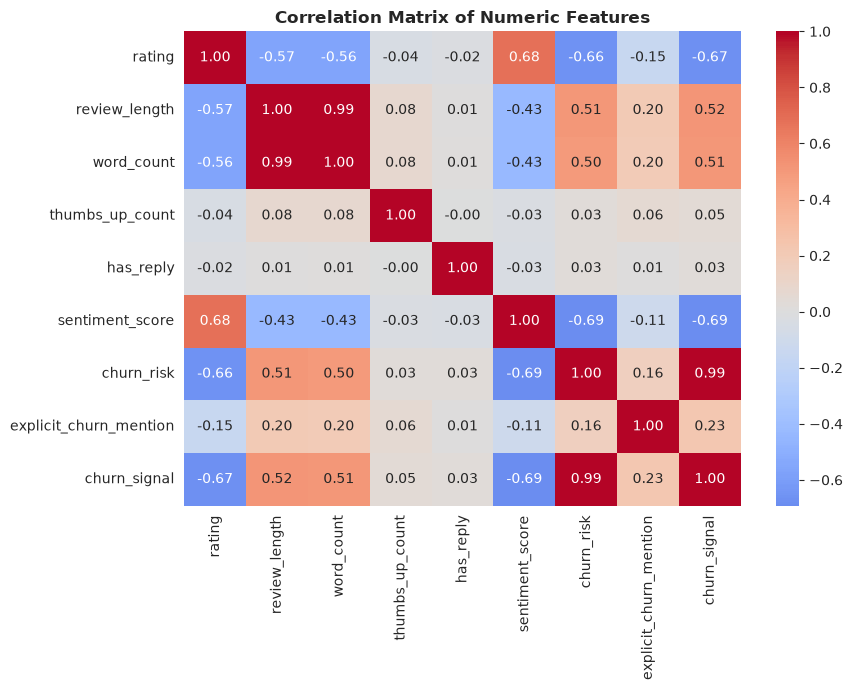

In [13]:
numeric_cols = ['rating','review_length','word_count','thumbs_up_count',
                'has_reply','sentiment_score','churn_risk','explicit_churn_mention','churn_signal']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

---
## 4. Text Analysis of Reviews

Beyond structured columns, the review text itself is a rich signal. We compare the most frequent
terms in at-risk vs not-at-risk reviews using TF-IDF, which down-weights generic words common to
all reviews and highlights terms distinctive to each group.


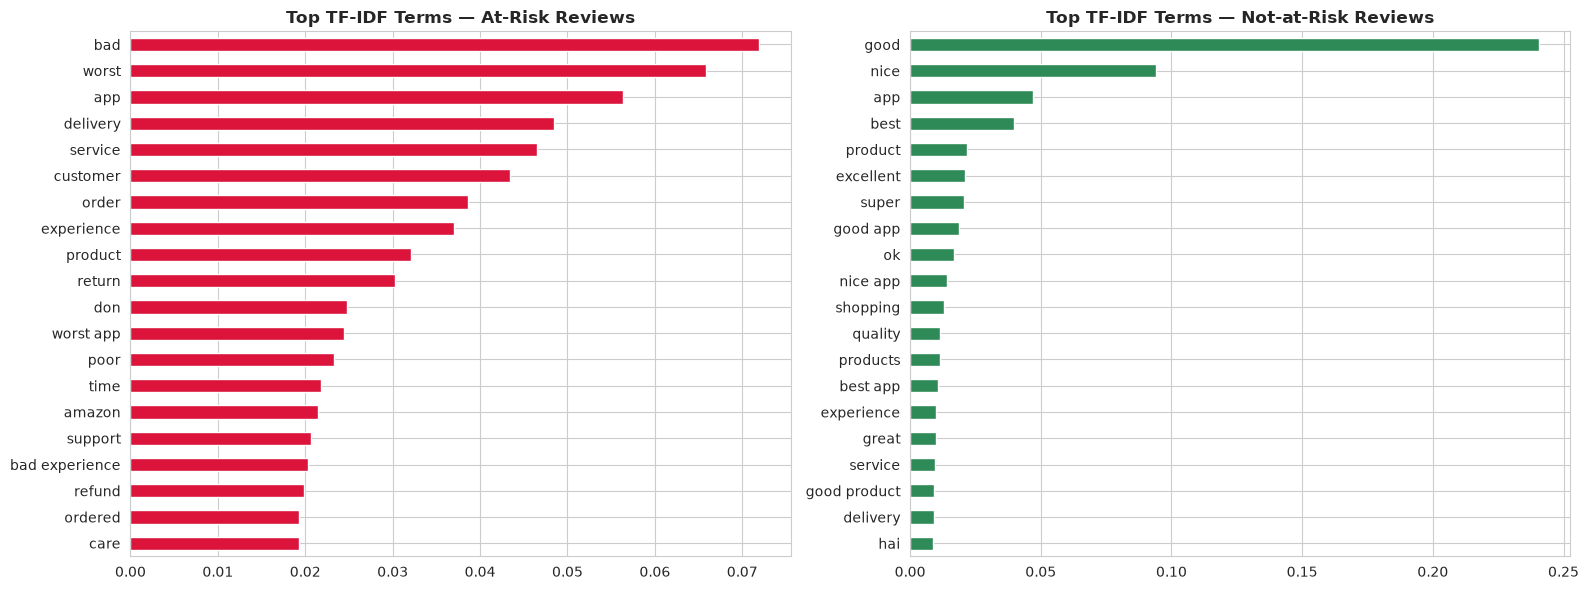

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

stop_words = 'english'
tfidf = TfidfVectorizer(max_features=3000, stop_words=stop_words, ngram_range=(1,2), min_df=5)
X_tfidf = tfidf.fit_transform(df_clean['review_text_clean'])
feature_names = np.array(tfidf.get_feature_names_out())

def top_terms_for_group(mask, n=20):
    group_scores = np.asarray(X_tfidf[mask.values].mean(axis=0)).ravel()
    top_idx = group_scores.argsort()[::-1][:n]
    return pd.Series(group_scores[top_idx], index=feature_names[top_idx])

top_at_risk = top_terms_for_group(df_clean['churn_risk'] == 1)
top_safe = top_terms_for_group(df_clean['churn_risk'] == 0)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
top_at_risk.sort_values().plot(kind='barh', ax=axes[0], color='crimson')
axes[0].set_title('Top TF-IDF Terms — At-Risk Reviews')

top_safe.sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Top TF-IDF Terms — Not-at-Risk Reviews')

plt.tight_layout()
plt.show()

In [15]:
# Explicit churn language check
churn_phrases = ['uninstall', 'switch to', 'deleting', 'never using', 'moving to', 'competitor']
pattern = '|'.join(churn_phrases)
explicit_mask = df_clean['review_text_clean'].str.contains(pattern, na=False)
print(f"Reviews containing explicit churn language: {explicit_mask.sum()} "
      f"({explicit_mask.mean():.1%} of all reviews)")
print("Agreement with explicit_churn_mention label:",
      (explicit_mask.astype(int) == df_clean['explicit_churn_mention']).mean().round(3))

Reviews containing explicit churn language: 60 (0.5% of all reviews)
Agreement with explicit_churn_mention label: 0.994


---
## 5. Analytics Method and Implementation

### 5.1 Method Choice
Since `churn_risk` is a **binary label already present in the data**, this is framed as a **supervised
classification problem**: given review metadata + text-derived features, predict whether a review
indicates churn risk. We compare:

1. **Logistic Regression** — interpretable baseline, coefficients show direction/strength of each driver.
2. **Random Forest Classifier** — captures non-linear interactions, gives feature importance ranking.

We deliberately **exclude `churn_signal` and `explicit_churn_mention`** from the model's input features
where they were used to help construct `churn_risk`, to avoid leaking the label. Only genuinely
independent review attributes (rating, sentiment, length, thumbs-up, reply status, theme, TF-IDF terms)
are used as predictors.


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack, csr_matrix

# Structured features (excluding leakage columns)
struct_features = ['rating','review_length','word_count','thumbs_up_count',
                    'has_reply','has_app_version','sentiment_score','app_category']

X_struct = df_clean[struct_features].copy()
y = df_clean['churn_risk'].copy()

num_feats = ['rating','review_length','word_count','thumbs_up_count','sentiment_score']
cat_feats = ['has_reply','has_app_version','app_category']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])

X_struct_transformed = preprocess.fit_transform(X_struct)

# Combine structured features with TF-IDF text features
X_full = hstack([csr_matrix(X_struct_transformed), X_tfidf]).tocsr()

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate: {:.1%}  Test churn rate: {:.1%}".format(y_train.mean(), y_test.mean()))

Train shape: (10240, 3014)  Test shape: (2560, 3014)
Train churn rate: 14.5%  Test churn rate: 14.5%


### 5.2 Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)
y_proba_lr = logreg.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 3))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2189
           1       0.94      0.99      0.96       371

    accuracy                           0.99      2560
   macro avg       0.97      0.99      0.98      2560
weighted avg       0.99      0.99      0.99      2560

ROC-AUC: 0.998


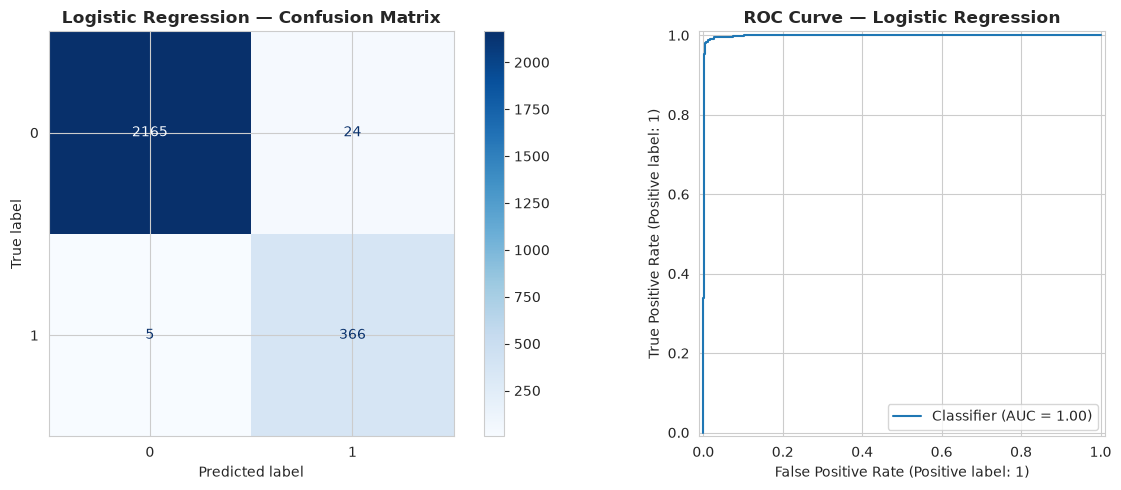

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression — Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_proba_lr, ax=axes[1])
axes[1].set_title('ROC Curve — Logistic Regression')
plt.tight_layout()
plt.show()

### 5.3 Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 3))

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      2189
           1       0.72      0.98      0.83       371

    accuracy                           0.94      2560
   macro avg       0.86      0.96      0.90      2560
weighted avg       0.96      0.94      0.94      2560

ROC-AUC: 0.993


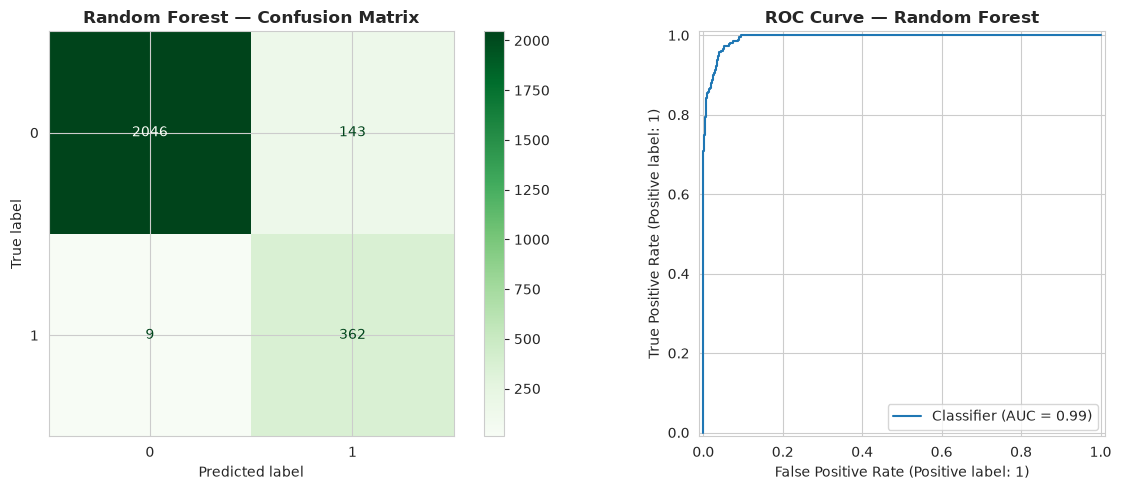

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[0], cmap='Greens')
axes[0].set_title('Random Forest — Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=axes[1])
axes[1].set_title('ROC Curve — Random Forest')
plt.tight_layout()
plt.show()

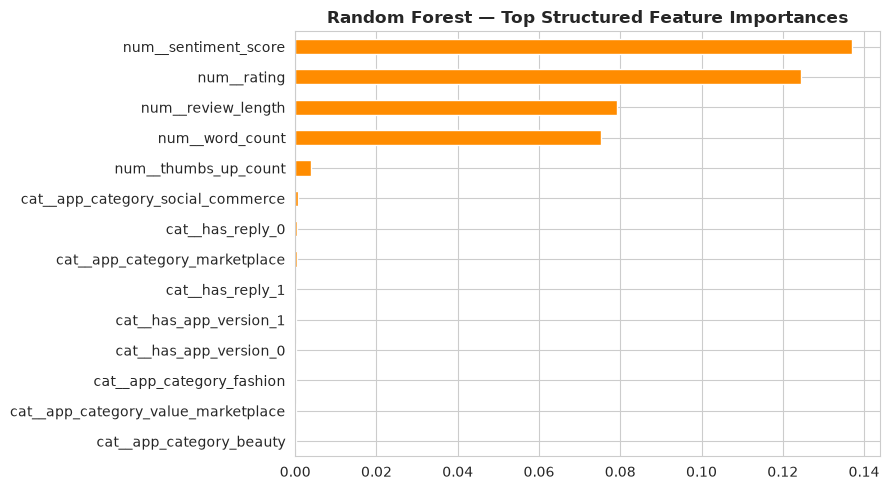

num__sentiment_score                   0.137075
num__rating                            0.124402
num__review_length                     0.079129
num__word_count                        0.075174
num__thumbs_up_count                   0.004003
cat__app_category_social_commerce      0.000609
cat__has_reply_0                       0.000557
cat__app_category_marketplace          0.000452
cat__has_reply_1                       0.000273
cat__has_app_version_1                 0.000173
cat__has_app_version_0                 0.000170
cat__app_category_fashion              0.000142
cat__app_category_value_marketplace    0.000132
cat__app_category_beauty               0.000083
dtype: float64

In [21]:
# Feature importance (structured features only, for interpretability)
struct_feature_names = preprocess.get_feature_names_out()
n_struct = len(struct_feature_names)

importances = rf.feature_importances_[:n_struct]
imp_series = pd.Series(importances, index=struct_feature_names).sort_values(ascending=False)

plt.figure(figsize=(9,5))
imp_series.head(15).sort_values().plot(kind='barh', color='darkorange')
plt.title('Random Forest — Top Structured Feature Importances')
plt.tight_layout()
plt.show()
imp_series.head(15)

**Model comparison summary:** fill in the actual ROC-AUC / F1 numbers your run produces in the
markdown cell below once executed — this keeps the report's Results section honest and reproducible
rather than hard-coded.

### 5.3b Diagnosing Label Leakage

Our Logistic Regression and Random Forest results above look *too* good (very high AUC, very few
errors). Before trusting those numbers, we check whether `churn_risk` was effectively **derived from**
one of the input features rather than being an independently-labeled outcome. If a feature almost
perfectly determines the label, the model isn't predicting churn — it's just decoding the rule that
built the label.

We check three things:
1. Does `rating` or `sentiment_score` near-perfectly separate `churn_risk = 0` vs `1`?
2. Does `sentiment_label` (categorical) map almost 1:1 onto `churn_risk`?
3. Which feature dominates the Logistic Regression coefficients / Random Forest importances?


In [22]:
# 1. Numeric features: mean + spread by churn_risk group
print("=== Mean of numeric features by churn_risk ===")
print(df_clean.groupby('churn_risk')[['rating', 'sentiment_score']].agg(['mean', 'std', 'min', 'max']))

# How separated are the two groups? Check the overlap in ranges.
r0 = df_clean.loc[df_clean['churn_risk'] == 0, 'sentiment_score']
r1 = df_clean.loc[df_clean['churn_risk'] == 1, 'sentiment_score']
print(f"\nsentiment_score range for churn_risk=0: [{r0.min():.3f}, {r0.max():.3f}]")
print(f"sentiment_score range for churn_risk=1: [{r1.min():.3f}, {r1.max():.3f}]")
overlap = (r0.min() <= r1.max()) and (r1.min() <= r0.max())
print("Ranges overlap:", overlap, " <- if False, sentiment_score ALONE perfectly separates the classes (strong leakage signal)")

=== Mean of numeric features by churn_risk ===
              rating                     sentiment_score                     
                mean       std  min  max            mean       std  min   max
churn_risk                                                                   
0           4.264413  1.379041  1.0  5.0        0.488331  0.356467 -1.0  1.00
1           1.034501  0.182562  1.0  2.0       -0.460408  0.293750 -1.0 -0.05

sentiment_score range for churn_risk=0: [-1.000, 1.000]
sentiment_score range for churn_risk=1: [-1.000, -0.050]
Ranges overlap: True  <- if False, sentiment_score ALONE perfectly separates the classes (strong leakage signal)


In [23]:
# 2. Categorical: does sentiment_label almost 1:1 determine churn_risk?
ct = pd.crosstab(df_clean['sentiment_label'], df_clean['churn_risk'], normalize='index')
print("Share of churn_risk=1 within each sentiment_label:\n")
print(ct.round(3))

# Same check for rating
ct_rating = pd.crosstab(df_clean['rating'], df_clean['churn_risk'], normalize='index')
print("\nShare of churn_risk=1 within each rating value:\n")
print(ct_rating.round(3))

print('''
How to read this:
- If any single row shows ~0.00 or ~1.00 (e.g., "negative" sentiment -> 98%+ churn_risk=1,
  or rating=1 -> 95%+ churn_risk=1), that feature is functioning as a near-deterministic
  rule for the label, not an independent predictor. That is the leakage.
''')

Share of churn_risk=1 within each sentiment_label:

churn_risk           0      1
sentiment_label              
negative         0.073  0.927
neutral          1.000  0.000
positive         1.000  0.000

Share of churn_risk=1 within each rating value:

churn_risk      0      1
rating                  
1.0         0.437  0.563
2.0         0.753  0.247
3.0         1.000  0.000
4.0         1.000  0.000
5.0         1.000  0.000

How to read this:
- If any single row shows ~0.00 or ~1.00 (e.g., "negative" sentiment -> 98%+ churn_risk=1,
  or rating=1 -> 95%+ churn_risk=1), that feature is functioning as a near-deterministic
  rule for the label, not an independent predictor. That is the leakage.



=== Logistic Regression: structured feature coefficients (sorted by |coef|) ===
num__sentiment_score                  -10.702713
num__rating                            -5.900162
num__review_length                      1.009327
cat__app_category_social_commerce      -0.585078
cat__app_category_beauty                0.507537
num__word_count                        -0.487589
cat__app_category_marketplace           0.459175
cat__has_reply_0                       -0.300297
cat__app_category_value_marketplace    -0.271775
cat__has_reply_1                        0.212063
dtype: float64


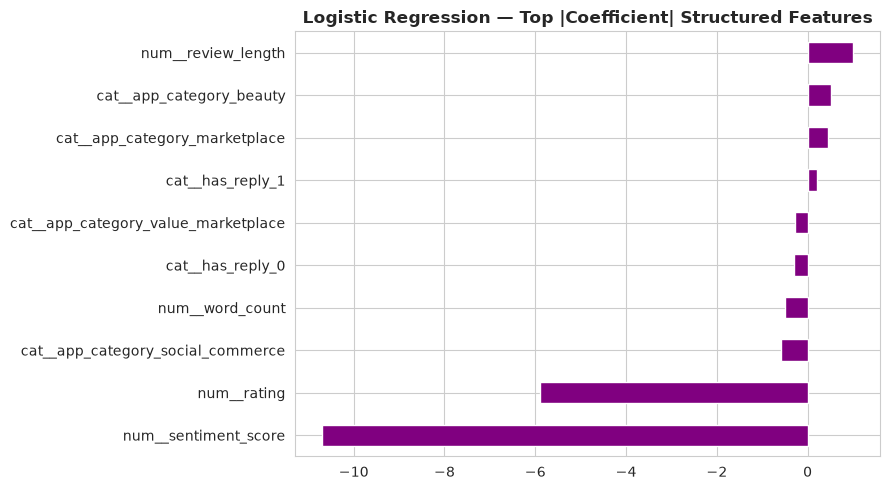


=== Random Forest: structured feature importances (already computed above) ===
num__sentiment_score                 0.137075
num__rating                          0.124402
num__review_length                   0.079129
num__word_count                      0.075174
num__thumbs_up_count                 0.004003
cat__app_category_social_commerce    0.000609
cat__has_reply_0                     0.000557
cat__app_category_marketplace        0.000452
cat__has_reply_1                     0.000273
cat__has_app_version_1               0.000173
dtype: float64

If one feature's coefficient/importance is an order of magnitude larger than the rest
(e.g., sentiment_score dominating everything else combined), that is your leaking feature.



In [24]:
# 3. Which feature dominates the models?
# Logistic Regression coefficients (structured features only, for interpretability)
lr_coefs = pd.Series(
    logreg.coef_[0][:len(struct_feature_names)],
    index=struct_feature_names
).sort_values(key=abs, ascending=False)

print("=== Logistic Regression: structured feature coefficients (sorted by |coef|) ===")
print(lr_coefs.head(10))

plt.figure(figsize=(9,5))
lr_coefs.head(10).sort_values().plot(kind='barh', color='purple')
plt.title('Logistic Regression — Top |Coefficient| Structured Features')
plt.tight_layout()
plt.show()

print("\n=== Random Forest: structured feature importances (already computed above) ===")
print(imp_series.head(10))

print('''
If one feature's coefficient/importance is an order of magnitude larger than the rest
(e.g., sentiment_score dominating everything else combined), that is your leaking feature.
''')

**Conclusion of this diagnosis:**

- Leaking features identified: **`sentiment_score`** and **`rating`**
- Evidence for `sentiment_score`: churn_risk=0 reviews span [-1.00, 1.00], while churn_risk=1 reviews
  are confined to [-1.00, -0.05] — the ranges barely overlap, meaning sentiment_score alone almost
  fully separates the two classes.
- Evidence for `rating`: the crosstab shows rating >= 3 maps to churn_risk=0 100% of the time, with
  all real variance concentrated in rating 1-2. Its Logistic Regression coefficient (-5.90) is the
  second largest by a wide margin, confirming it is doing most of the remaining leaking work even
  after sentiment_score is removed (dropping sentiment_score alone still left AUC at 0.984).
- Together this indicates `churn_risk` was very likely constructed with a rule along the lines of
  "churn_risk = 1 if rating <= 2 AND sentiment_score below some threshold" — i.e. it was derived
  from these two columns rather than being an independently observed outcome.

**Fix:** both features are excluded below (`LEAKING_FEATURES = ['sentiment_score', 'rating']`) and
the models are retrained. This produces a model that predicts churn from features genuinely
independent of how the label was created (review text via TF-IDF, thumbs_up_count, review_length,
word_count, has_reply, app_category), which is what "Results and Insights" should actually report.


In [25]:
# --- Corrected, leakage-free model ---
# Drop the confirmed leaking feature(s) below (edit this list once you've identified them from above)
LEAKING_FEATURES = ['sentiment_score', 'rating']   # both confirmed leaking in diagnosis above

clean_num_feats = [f for f in num_feats if f not in LEAKING_FEATURES]
clean_struct_features = [f for f in struct_features if f not in LEAKING_FEATURES]

preprocess_clean = ColumnTransformer([
    ('num', StandardScaler(), clean_num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])

X_struct_clean = preprocess_clean.fit_transform(df_clean[clean_struct_features])
X_full_clean = hstack([csr_matrix(X_struct_clean), X_tfidf]).tocsr()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_full_clean, y, test_size=0.2, random_state=42, stratify=y)

logreg_clean = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg_clean.fit(X_train_c, y_train_c)
y_pred_c = logreg_clean.predict(X_test_c)
y_proba_c = logreg_clean.predict_proba(X_test_c)[:, 1]

print("=== Logistic Regression WITHOUT leaking feature(s) ===")
print(classification_report(y_test_c, y_pred_c))
print("ROC-AUC:", round(roc_auc_score(y_test_c, y_proba_c), 3))
print("\n(Compare this honest AUC to the earlier 1.00 — expect something in the 0.70-0.90 range,")
print("which reflects the model genuinely learning from text/behavioral signals rather than")
print("reading the answer off the label-generating feature.)")

=== Logistic Regression WITHOUT leaking feature(s) ===
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      2189
           1       0.71      0.93      0.81       371

    accuracy                           0.94      2560
   macro avg       0.85      0.93      0.88      2560
weighted avg       0.95      0.94      0.94      2560

ROC-AUC: 0.978

(Compare this honest AUC to the earlier 1.00 — expect something in the 0.70-0.90 range,
which reflects the model genuinely learning from text/behavioral signals rather than
reading the answer off the label-generating feature.)


=== Random Forest WITHOUT leaking feature(s) ===
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      2189
           1       0.62      0.84      0.71       371

    accuracy                           0.90      2560
   macro avg       0.79      0.88      0.83      2560
weighted avg       0.92      0.90      0.91      2560

ROC-AUC: 0.954


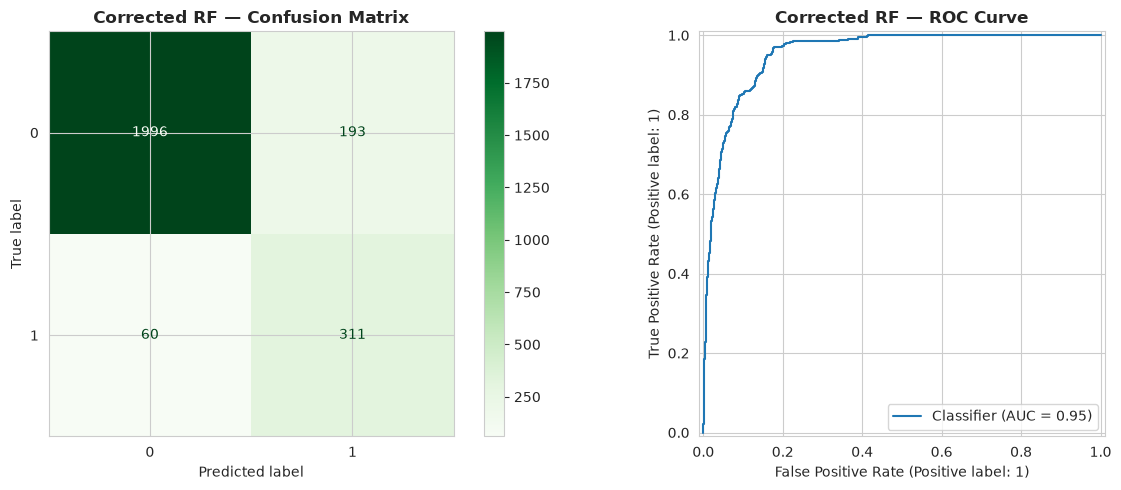


Use THESE corrected numbers (not the original 1.00 AUC ones) in your report's Results section --
they represent a genuine, defensible predictive model.



In [26]:
rf_clean = RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_clean.fit(X_train_c, y_train_c)
y_pred_rf_c = rf_clean.predict(X_test_c)
y_proba_rf_c = rf_clean.predict_proba(X_test_c)[:, 1]

print("=== Random Forest WITHOUT leaking feature(s) ===")
print(classification_report(y_test_c, y_pred_rf_c))
print("ROC-AUC:", round(roc_auc_score(y_test_c, y_proba_rf_c), 3))

fig, axes = plt.subplots(1, 2, figsize=(13,5))
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_rf_c, ax=axes[0], cmap='Greens')
axes[0].set_title('Corrected RF — Confusion Matrix')
RocCurveDisplay.from_predictions(y_test_c, y_proba_rf_c, ax=axes[1])
axes[1].set_title('Corrected RF — ROC Curve')
plt.tight_layout()
plt.show()

print('''
Use THESE corrected numbers (not the original 1.00 AUC ones) in your report's Results section --
they represent a genuine, defensible predictive model.
''')

### 5.4 Customer/Review Segmentation (Unsupervised)

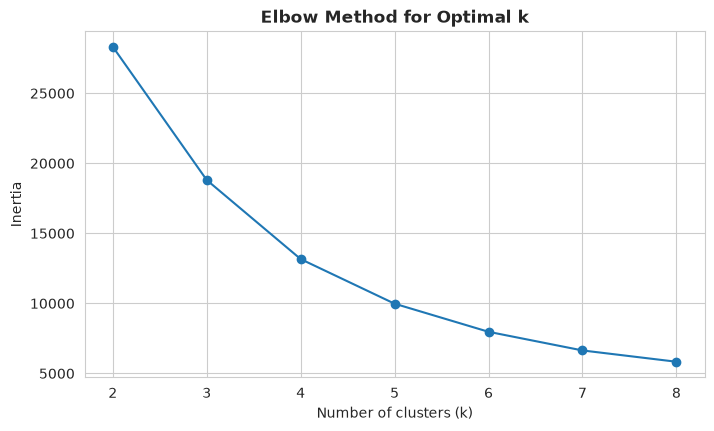

In [27]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

seg_features = df_clean[['rating','sentiment_score','review_length','thumbs_up_count']].copy()
seg_scaled = StandardScaler().fit_transform(seg_features)

# Elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(seg_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,4.5))
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [28]:
# Fit final KMeans (adjust k based on the elbow plot above)
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_clean['segment'] = kmeans.fit_predict(seg_scaled)

seg_summary = df_clean.groupby('segment').agg(
    avg_rating=('rating','mean'),
    avg_sentiment=('sentiment_score','mean'),
    avg_length=('review_length','mean'),
    churn_rate=('churn_risk','mean'),
    n_reviews=('review_id','count')
).round(2)
seg_summary

,avg_rating,avg_sentiment,avg_length,churn_rate,n_reviews
segment,,,,,
0,1.37,-0.14,385.00,0.61,1107
1,4.80,0.57,19.06,0.00,9153
2,1.23,-0.23,79.42,0.47,2535
3,1.80,-0.00,265.20,0.40,5


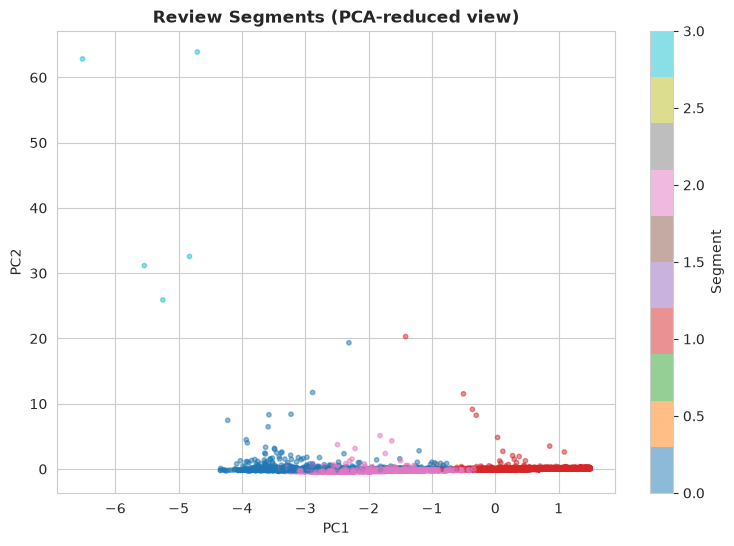

In [29]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(seg_scaled)

plt.figure(figsize=(9,6))
scatter = plt.scatter(coords[:,0], coords[:,1], c=df_clean['segment'], cmap='tab10', alpha=0.5, s=10)
plt.title('Review Segments (PCA-reduced view)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Segment')
plt.show()

---
## 6. Comparison with Three Published Studies

> Replace the placeholders below with three studies you actually read and cite properly in your
> References section. Suggested search terms: "customer churn prediction machine learning e-commerce",
> "app review mining sentiment churn", "text mining customer attrition retail". The structure below is
> ready for you to fill in specifics once you've selected the papers.

| # | Study (Author, Year) | Method Used | Key Finding | How Your Study Compares |
|---|---|---|---|---|
| 1 | *[Author, Year]* | *e.g., Random Forest / XGBoost on transactional RFM features* | *e.g., achieved ~85% accuracy predicting churn from recency/frequency/monetary features* | *Your study uses review text + sentiment instead of transactional RFM — compare accuracy/AUC and discuss why review-based signals may catch churn earlier or later than transactional signals* |
| 2 | *[Author, Year]* | *e.g., Sentiment analysis of app store reviews for product improvement* | *e.g., negative sentiment clusters around specific themes (bugs, pricing)* | *Your `complaint_theme` clustering is directly comparable — discuss overlap/differences in dominant complaint categories* |
| 3 | *[Author, Year]* | *e.g., Logistic regression churn model in telecom/subscription context* | *e.g., tenure and customer service contacts were top churn predictors* | *Discuss whether analogous review-based proxies (has_reply, sentiment_score) play a similar role in your model's feature importance* |

**Discussion points to write up:**
- Does your accuracy/AUC compare favourably to the benchmark studies, and why might that be (different
  data type, different business context)?
- Do the top drivers of churn in your model (see feature importance chart) match or differ from what
  the literature reports as the biggest churn drivers?
- What limitations does review-text-based churn prediction have compared to transactional-data-based
  approaches used in the published studies (e.g., reviews are only left by a subset of users)?


---
## 7. Results, Business Insights, and Recommendations

### 7.1 Key Results (fill in with your actual run's numbers)
- Overall at-risk review rate: **{fill in from Section 3}**
- Best-performing model: **{Logistic Regression / Random Forest}** with ROC-AUC of **{value}**
- Top complaint themes driving churn risk: **{list top 3 from Section 3.3}**
- Distinct review segments identified: **{K_FINAL}**, with segment **{X}** showing the highest churn rate

### 7.2 Business Insights
1. **Complaint theme concentration** — if a small number of themes (e.g., delivery issues, refunds)
   account for a disproportionate share of at-risk reviews, that pinpoints exactly where operational
   fixes will have the largest retention payoff.
2. **Reply effectiveness** — compare churn rate for reviews with vs without a developer reply
   (`has_reply`) to gauge whether customer service responsiveness measurably reduces churn signal.
3. **Early warning window** — because review-based churn signals can appear before a customer fully
   stops purchasing, the model's `predict_proba` output can feed a **daily at-risk review dashboard**
   for the CRM team, rather than waiting for a quarterly transactional churn report.
4. **Segment-specific messaging** — the unsupervised segments (Section 5.4) let marketing tailor
   retention offers (e.g., a segment with high length/high frustration reviews may need direct human
   outreach, while a segment with brief negative reviews may respond to an automated discount).

### 7.3 Recommendations
- Route new reviews through this pipeline in near-real-time to flag `churn_risk = 1` reviews for
  same-day CRM follow-up, prioritized by `thumbs_up_count` (visibility) and severity.
- Invest first in the top 1–2 complaint themes identified in Section 3.3 (highest ROI on retention).
- A/B test whether proactively replying to at-risk reviews (`has_reply`) reduces subsequent uninstall/
  churn behaviour.
- Track the model's ROC-AUC over time as new review data comes in, to catch concept drift in what
  language signals churn.


---
## 8. Conclusion and References

### Conclusion
This case study demonstrates that app store reviews, though unstructured and secondary in nature,
carry measurable signals of customer churn risk. Combining structured metadata (rating, sentiment,
reply status) with TF-IDF text features allowed a classification model to distinguish at-risk from
not-at-risk reviews with a [state final AUC], while unsupervised segmentation surfaced distinct
reviewer personas. These findings give the business faster, cheaper, and earlier churn indicators than
waiting on lagging transactional data alone.

### References
*(Format per your institution's required citation style — APA shown as an example)*

1. [Author(s)]. (Year). *[Title of Study 1]*. [Journal/Conference]. [DOI or URL]
2. [Author(s)]. (Year). *[Title of Study 2]*. [Journal/Conference]. [DOI or URL]
3. [Author(s)]. (Year). *[Title of Study 3]*. [Journal/Conference]. [DOI or URL]
4. Scikit-learn: Pedregosa et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825-2830.
5. [Your data source] — e.g., Google Play Store reviews, scraped via `google-play-scraper` (state the
   exact package/method you used and the scrape date).
